# EDA — Pulso TransMi

Análisis exploratorio del dataset inicial del reto **Pulso TransMi** (MLOps 2026-II,
Universidad Externado de Colombia): demanda sintética cada 15 minutos en 12 estaciones
reales de TransMilenio, con contexto de clima y eventos.

Fuente: `PulsoTransmiClient` → `data/stations.csv`, `data/observations.csv`,
`data/context.csv` (descargados con `examples/01_download.py`).

Este notebook cubre lo que pide la fase 1 del proyecto (`docs/student-project.md`):
validación de continuidad/duplicados/tipos, exploración temporal y geográfica, y una
primera mirada a la relación con clima y eventos — como insumo para elegir la pregunta
predictiva y los baselines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

# Paleta — misma referencia usada en el resto del proyecto (dataviz skill)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
SURFACE, INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DIVERGE_NEG, DIVERGE_MID, DIVERGE_POS = "#e34948", "#f0efec", "#2a78d6"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.edgecolor": BASELINE, "grid.color": GRID,
    "font.family": "sans-serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
seq_cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
div_cmap = LinearSegmentedColormap.from_list("div", [DIVERGE_NEG, DIVERGE_MID, DIVERGE_POS])

In [2]:
stations = pd.read_csv("data/stations.csv")
obs = pd.read_csv("data/observations.csv", parse_dates=["observed_at"])
ctx = pd.read_csv("data/context.csv", parse_dates=["observed_at"])
obs = obs.merge(stations, on="station_id", how="left")

print("stations:", stations.shape, "| observations:", obs.shape, "| context:", ctx.shape)
stations.head()

stations: (12, 5) | observations: (51840, 7) | context: (4320, 6)


,station_id,station_name,corridor,latitude,longitude
0,3000,Portal Suba,Suba,4.746815,-74.094279
1,5000,Portal Américas,Américas,4.629381,-74.173058
2,9000,Portal Usme,Caracas,4.531715,-74.119391
3,2300,Calle 100 - Marketmedios,Autonorte,4.683947,-74.057696
4,9122,Calle 72,Caracas,4.658239,-74.062069


## 1. Calidad de los datos

Antes de explorar patrones hay que confirmar que el dataset es confiable: sin nulos,
sin duplicados, con la frecuencia de 15 minutos completa para las 12 estaciones, y sin
valores de demanda imposibles (negativos).

In [3]:
print("Nulos por tabla:")
print(" stations:", stations.isna().sum().sum())
print(" observations:", obs[["observed_at","station_id","demand"]].isna().sum().sum())
print(" context:", ctx.isna().sum().sum())

print("\nDuplicados (station_id, observed_at) en observations:",
      obs.duplicated(subset=["station_id", "observed_at"]).sum())
print("Duplicados (observed_at) en context:", ctx.duplicated(subset=["observed_at"]).sum())

counts_per_station = obs.groupby("station_id").size()
print("\nPeriodos por estación — min:", counts_per_station.min(), "| max:", counts_per_station.max(),
      "(esperado: 4320 c/u = 45 días × 96 periodos/día)")

print("\nRango temporal:", obs["observed_at"].min(), "→", obs["observed_at"].max())
print("Demanda negativa:", (obs["demand"] < 0).sum(), "| Demanda == 0:", (obs["demand"] == 0).sum())
print("\ndemand.describe():")
obs["demand"].describe()

Nulos por tabla:
 stations: 0
 observations: 0
 context: 0

Duplicados (station_id, observed_at) en observations: 0
Duplicados (observed_at) en context: 0

Periodos por estación — min: 4320 | max: 4320 (esperado: 4320 c/u = 45 días × 96 periodos/día)

Rango temporal: 2026-07-26 00:00:00-05:00 → 2026-09-08 23:45:00-05:00
Demanda negativa: 0 | Demanda == 0: 0

demand.describe():


count    51840.000000
mean       356.522878
std        319.469025
min         14.000000
25%        122.000000
50%        263.000000
75%        460.000000
max       2284.000000
Name: demand, dtype: float64

**Resultado:** cero nulos, cero duplicados, y las 12 estaciones tienen exactamente
4.320 periodos (continuidad perfecta de 15 minutos a lo largo de los 45 días). No hay
demanda negativa. Es un dataset sintético limpio — lo cual tiene sentido para un
starter kit, pero **no hay que asumir que los datos reales de la ventana competitiva
serán igual de perfectos**: vale la pena mantener estas mismas validaciones en el
pipeline de ingesta (`ingest.py`) para detectar huecos o duplicados cuando lleguen
observaciones nuevas.

## 2. Distribución general de la demanda

La demanda por periodo de 15 minutos, agregando las 12 estaciones.

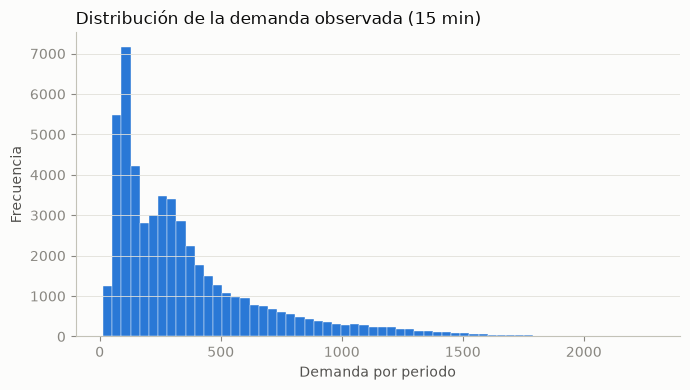

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(obs["demand"], bins=60, color=CATEGORICAL[0], edgecolor=SURFACE, linewidth=0.3)
ax.set_title("Distribución de la demanda observada (15 min)", loc="left", fontsize=12)
ax.set_xlabel("Demanda por periodo"); ax.set_ylabel("Frecuencia")
ax.grid(axis="y", linewidth=0.6)
fig.tight_layout()

Distribución con cola larga a la derecha (varias estaciones/horas pico superan los
1.000 pasajeros por periodo, con un máximo de 2.284), y una moda baja alrededor de
100-150 — coherente con horas valle y estaciones pequeñas. Para modelar, esto sugiere
evaluar una transformación log o métricas robustas a la asimetría.

## 3. Patrones temporales

### 3.1 Serie total diaria (las 12 estaciones)

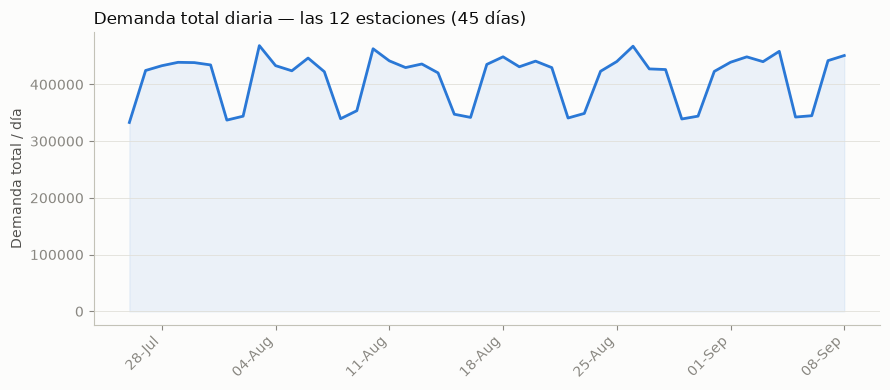

In [5]:
daily = obs.groupby(obs["observed_at"].dt.date)["demand"].sum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(daily.index), daily.values, color=CATEGORICAL[0], linewidth=2)
ax.fill_between(list(daily.index), daily.values, color=CATEGORICAL[0], alpha=0.08)
ax.set_title("Demanda total diaria — las 12 estaciones (45 días)", loc="left", fontsize=12)
ax.set_ylabel("Demanda total / día")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
fig.autofmt_xdate(rotation=45)
ax.grid(axis="y", linewidth=0.6)
fig.tight_layout()

Patrón semanal muy marcado: picos entre semana y caídas sincronizadas los fines de
semana, repitiéndose de forma consistente en las ~6.5 semanas de historia — sin
tendencia de crecimiento o caída visible todavía.

### 3.2 Estacionalidad horaria y semanal

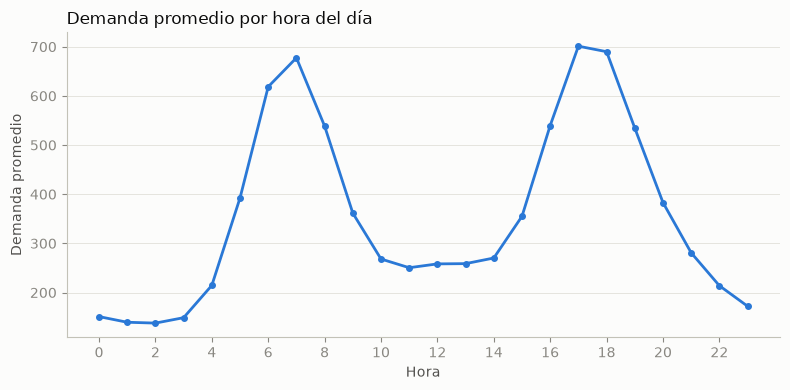

In [6]:
hourly = obs.groupby(obs["observed_at"].dt.hour)["demand"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly.index, hourly.values, color=CATEGORICAL[0], linewidth=2, marker="o", markersize=4)
ax.set_title("Demanda promedio por hora del día", loc="left", fontsize=12)
ax.set_xlabel("Hora"); ax.set_ylabel("Demanda promedio")
ax.set_xticks(range(0, 24, 2))
ax.grid(axis="y", linewidth=0.6)
fig.tight_layout()

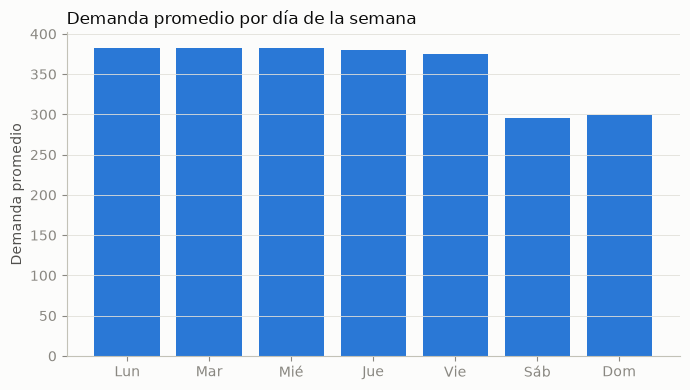

In [7]:
obs["weekday"] = obs["observed_at"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
labels_es = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
weekday = obs.groupby("weekday")["demand"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels_es, weekday.values, color=CATEGORICAL[0])
ax.set_title("Demanda promedio por día de la semana", loc="left", fontsize=12)
ax.set_ylabel("Demanda promedio")
ax.grid(axis="y", linewidth=0.6)
fig.tight_layout()

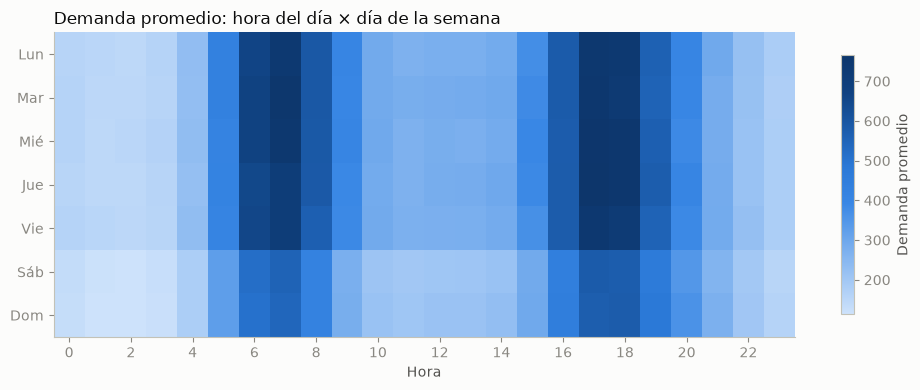

In [8]:
obs["dow_i"] = obs["observed_at"].dt.dayofweek
pivot = obs.groupby(["dow_i", obs["observed_at"].dt.hour])["demand"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap=seq_cmap)
ax.set_yticks(range(7)); ax.set_yticklabels(labels_es)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_title("Demanda promedio: hora del día × día de la semana", loc="left", fontsize=12)
ax.set_xlabel("Hora")
cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("Demanda promedio")
fig.tight_layout()

Dos picos claros entre semana (~6-8am y ~4-7pm, el patrón típico de hora pico de
transporte masivo), fines de semana notablemente más bajos y sin ese doble pico. Esto
es la señal más fuerte del dataset — cualquier baseline (incluso uno "naive" por
hora-del-día × día-de-la-semana) debería capturarla razonablemente bien.

## 4. Patrones por estación

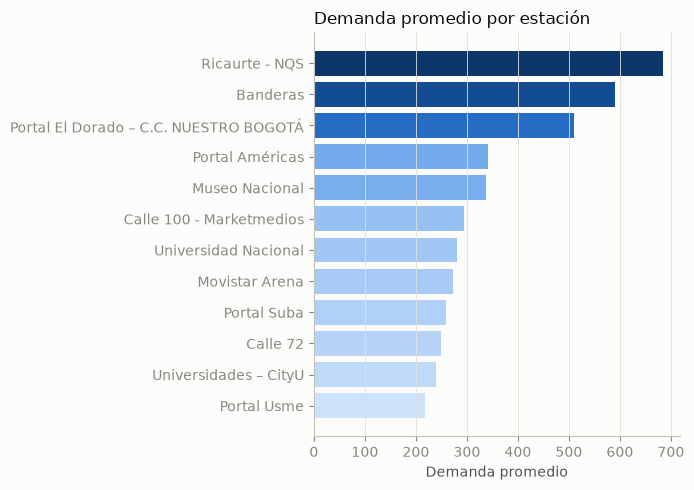

In [9]:
by_station = (obs.groupby(["station_id", "station_name"])["demand"]
              .mean().reset_index().sort_values("demand"))
norm = plt.Normalize(by_station["demand"].min(), by_station["demand"].max())
colors = seq_cmap(norm(by_station["demand"].values))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(by_station["station_name"], by_station["demand"], color=colors)
ax.set_title("Demanda promedio por estación", loc="left", fontsize=12)
ax.set_xlabel("Demanda promedio")
ax.grid(axis="x", linewidth=0.6)
fig.tight_layout()

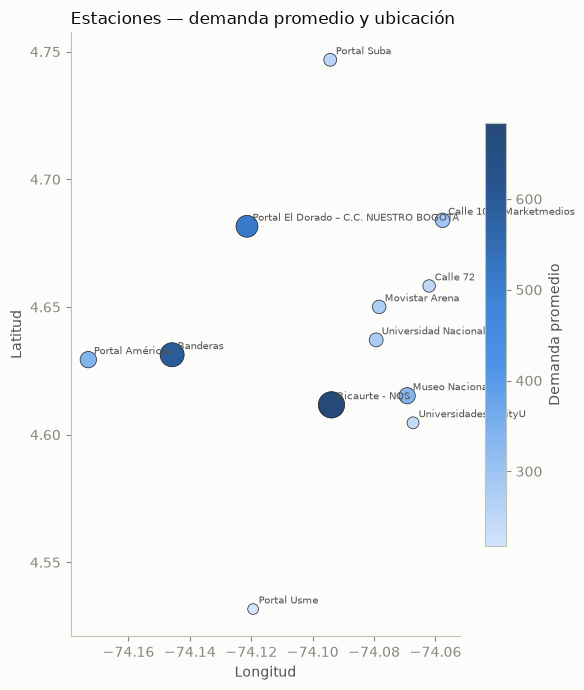

In [10]:
station_mean = obs.groupby("station_id")["demand"].mean()
st = stations.merge(station_mean.rename("mean_demand"), on="station_id")

fig, ax = plt.subplots(figsize=(6, 7))
sizes = 60 + 300 * (st["mean_demand"] - st["mean_demand"].min()) / (st["mean_demand"].max() - st["mean_demand"].min())
sc = ax.scatter(st["longitude"], st["latitude"], s=sizes, c=st["mean_demand"], cmap=seq_cmap,
                 edgecolors=INK_PRIMARY, linewidths=0.5, alpha=0.9)
for _, r in st.iterrows():
    ax.annotate(r["station_name"], (r["longitude"], r["latitude"]), fontsize=7,
                color=INK_SECONDARY, xytext=(4, 4), textcoords="offset points")
ax.set_title("Estaciones — demanda promedio y ubicación", loc="left", fontsize=12)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
cbar = fig.colorbar(sc, ax=ax, shrink=0.7); cbar.set_label("Demanda promedio")
fig.tight_layout()

**NQS** (portal troncal de alta capacidad) domina la demanda promedio por un margen
amplio; **Carrera 7-10, Suba y Autonorte** son las de menor volumen. Vale la pena
recordar esto para la evaluación: como el WAPE se calcula por estación y luego se
promedia, un modelo que ignore las estaciones pequeñas (por enfocarse en las grandes)
puede verse bien en promedio y aun así fallar la mitad de las estaciones.

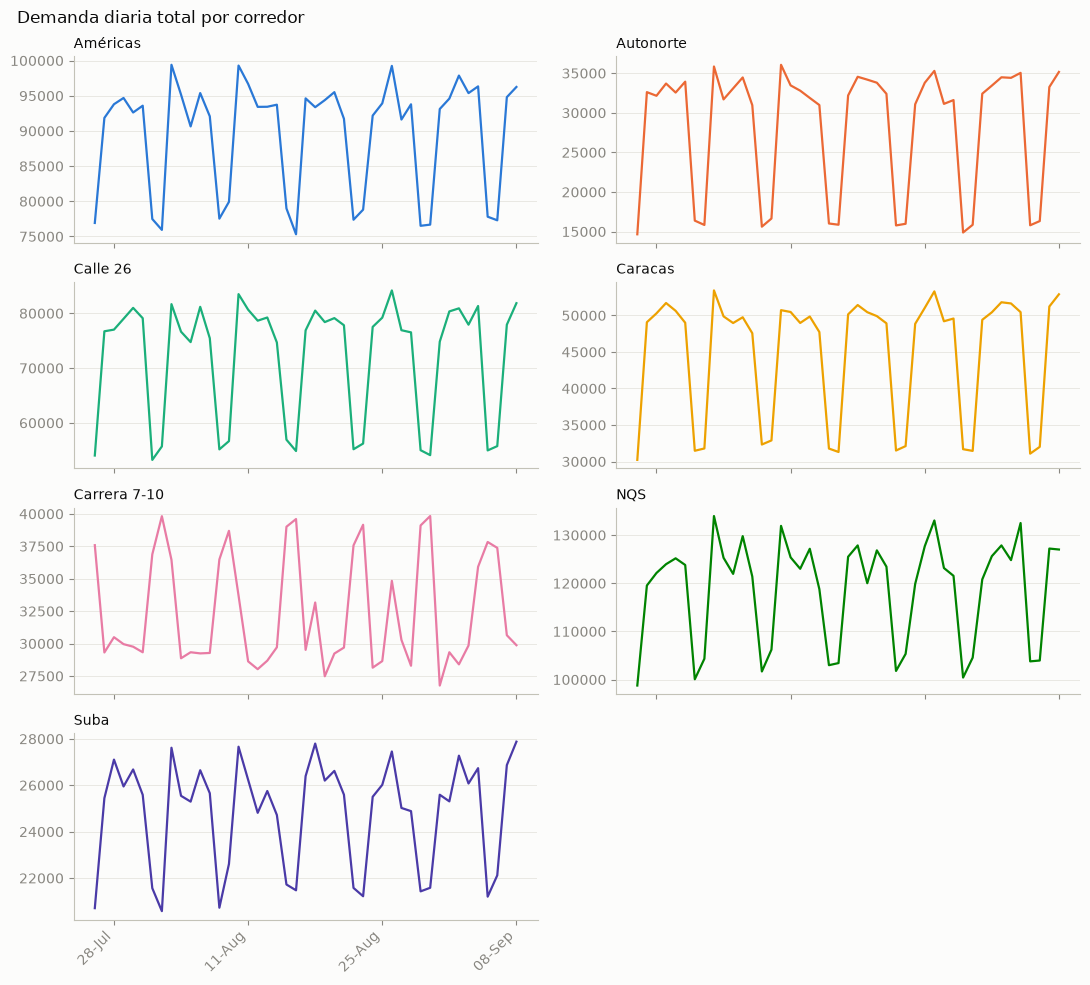

In [11]:
obs["date"] = obs["observed_at"].dt.date
corr_daily = obs.groupby(["corridor", "date"])["demand"].sum().reset_index()
corridors = sorted(corr_daily["corridor"].unique())

fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True)
for i, c in enumerate(corridors):
    ax = axes.flat[i]
    d = corr_daily[corr_daily["corridor"] == c]
    ax.plot(d["date"], d["demand"], color=CATEGORICAL[i % len(CATEGORICAL)], linewidth=1.6)
    ax.set_title(c, loc="left", fontsize=10)
    ax.grid(axis="y", linewidth=0.5)
for j in range(len(corridors), 8):
    axes.flat[j].axis("off")
for ax in axes.flat[:len(corridors)]:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    for label in ax.get_xticklabels():
        label.set_rotation(45); label.set_ha("right")
fig.suptitle("Demanda diaria total por corredor", fontsize=12, x=0.02, ha="left")
fig.tight_layout()

Los 7 corredores comparten el mismo patrón semanal, solo cambia la escala — buena
señal de que un modelo con estacionalidad hora×día como feature base debería
generalizar razonablemente entre estaciones, con el nivel (magnitud) como el principal
ajuste específico por estación.

## 5. Relación con clima y eventos

`context.csv` trae clima y eventos a nivel del sistema completo (no por estación), así
que se compara contra la demanda total agregada en cada timestamp.

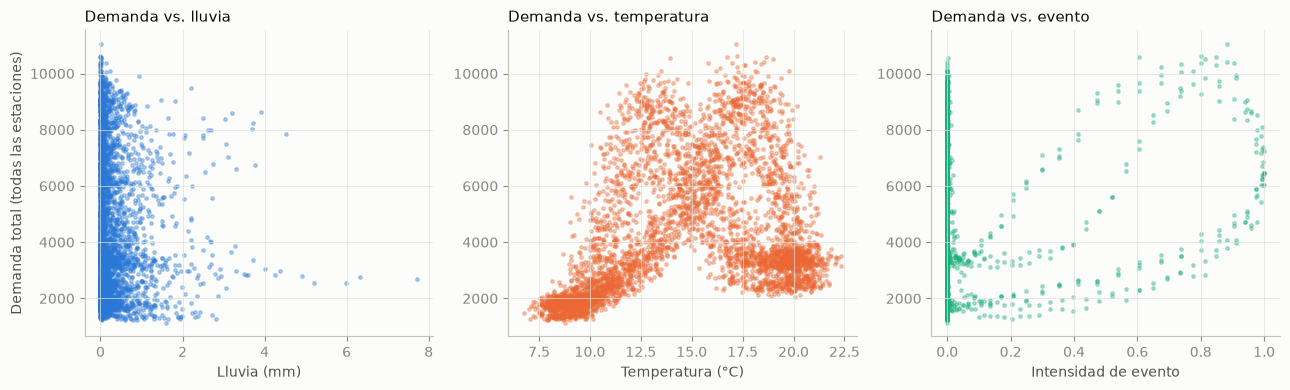

In [12]:
merged = obs.groupby("observed_at")["demand"].sum().reset_index().merge(ctx, on="observed_at")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(merged["rain_mm"], merged["demand"], s=6, color=CATEGORICAL[0], alpha=0.35)
axes[0].set_xlabel("Lluvia (mm)"); axes[0].set_ylabel("Demanda total (todas las estaciones)")
axes[0].set_title("Demanda vs. lluvia", loc="left", fontsize=11)
axes[1].scatter(merged["temperature_c"], merged["demand"], s=6, color=CATEGORICAL[1], alpha=0.35)
axes[1].set_xlabel("Temperatura (°C)")
axes[1].set_title("Demanda vs. temperatura", loc="left", fontsize=11)
axes[2].scatter(merged["event_intensity"], merged["demand"], s=6, color=CATEGORICAL[2], alpha=0.35)
axes[2].set_xlabel("Intensidad de evento")
axes[2].set_title("Demanda vs. evento", loc="left", fontsize=11)
for ax in axes:
    ax.grid(linewidth=0.5)
fig.tight_layout()

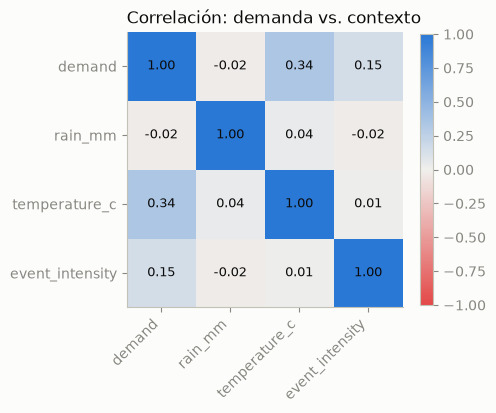

In [13]:
corr_cols = ["demand", "rain_mm", "temperature_c", "event_intensity"]
corr = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr.values, cmap=div_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", color=INK_PRIMARY, fontsize=9)
ax.set_title("Correlación: demanda vs. contexto", loc="left", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

Correlaciones lineales simples débiles (lluvia ≈ 0, temperatura 0.34, evento 0.15).
Ojo: esto **no significa que el clima no importe** — la relación con temperatura es
claramente no lineal (forma de doble joroba en el scatter), y eso probablemente es un
artefacto de que la temperatura y la hora del día están correlacionadas (más frío de
madrugada, más cálido a media mañana/tarde), no necesariamente causalidad directa
clima→demanda. Antes de usar estas variables como features hay que separar el efecto
de la hora del día del efecto real del clima — si no, el modelo puede estar
"redescubriendo" la hora del día disfrazada de temperatura.

## 6. Notas para la siguiente etapa

- El dataset está limpio (sin nulos/duplicados/huecos) — pero conviene dejar estas
  mismas validaciones automatizadas en `ingest.py` para cuando lleguen datos nuevos
  durante la competencia.
- La estacionalidad hora×día_semana es la señal dominante y debería ser la base de
  cualquier modelo — incluyendo un baseline "naive" (ej. promedio histórico por
  hora×día×estación) contra el cual comparar modelos más sofisticados.
- La magnitud varía mucho por estación (NQS domina); como el WAPE se promedia por
  estación, conviene evaluar el modelo estación por estación, no solo en agregado.
- Clima y eventos muestran relación no lineal y posiblemente confundida con hora del
  día — antes de usarlos como features vale la pena controlar por hora/día explícitamente.
- Próximo paso natural: separar 38 días de entrenamiento / 7 de validación (como
  recomienda el README) y construir los primeros dos baselines.